In [3]:
from string import digits
from IPython.display import display, SVG # type: ignore
import io
import matplotlib.pyplot as plt
import networkx as nx

import jax.numpy as jnp

from jax.core import Literal
from probjax.core.custom_primitives.random_variable import rv_p


COMPUTE_GRAPH_NODE_STYLES = {
    "const": dict(
        style="",
        color="goldenrod1",
        shape="circle",
        fontsize=6,
        margin=0.01,
        width=0.1,
        height=0.1,
        regular=True,
    ),
    "invar": dict(
        fillcolor="mediumspringgreen",
        style="filled",
        shape="circle",
        fontsize=9,
        width=0.2,
        height=0.2,
        margin=0.01,
        regular=True,
    ),
    "outvar": dict(
        style="filled",
        fillcolor="indianred1",
        color="black",
        shape="circle",
        width=0.2,
        height=0.2,
        fontsize=9,
        margin=0.01,
        regular=True,
    ),
    "operation": dict(
        shape="box",
        color="black",
        fontsize=9,
        regular=True,
        margin=0.01,
        width=0.2,
        height=0.2,
    ),
    "latent": dict(
        style="filled",
        color="cornflowerblue",
        shape="circle",
        width=0.2,
        height=0.2,
        fontsize=8,
        margin=0.01,
        regular=True,
    ),
    "intermediate": dict(
        style="filled",
        color="lightgrey",
        shape="circle",
        width=0.2,
        height=0.2,
        fontsize=8,
        margin=0.01,
        regular=True,
    ),
}

In [37]:
import jax
from jax import numpy as jnp

from probjax.distributions import Normal
from probjax.core.custom_primitives.random_variable import rv, rv_p

p = rv(Normal(0.,1.), "X")

def f(x):
    x1,x2 = jnp.split(x,2)
    x = x1 + 1
    y = jnp.sin(x2)
    out = jnp.concatenate([x,y])
    out += p(jax.random.PRNGKey(0))
    return out

def f(theta):
    x0 = p(jax.random.PRNGKey(0))
    xs = []
    for i in range(5):
        x0 = x0 + x0* theta
        xs.append(x0)
    return xs



jaxpr = jax.make_jaxpr(f)(jnp.ones(2))

In [38]:
def to_networkx(jaxpr, var_name_fn, compute_name_fn):
    graph = nx.DiGraph()
    constvars = jaxpr.constvars
    invars = jaxpr.invars
    outvars = jaxpr.outvars
    eqns = jaxpr.eqns

    # Adding constants
    for n in constvars:
        graph.add_node(
            var_name_fn(n),
            tag="const",
            val=n,
        )

    # Adding invars
    for n in invars:
        graph.add_node(var_name_fn(n), tag="invar", val=n)

    # Adding outvars
    for n in outvars:
        graph.add_node(var_name_fn(n), tag="outvar", val=n)

    # Adding equations
    for i, eqn in enumerate(eqns):
        # Add function node
        graph.add_node(
            f"f{i}",
            tag="operation",
            index=i,
            xlabel=compute_name_fn(eqn),
        )

        # Add invars
        in_vars = eqn.invars
        for n in in_vars:
            name = var_name_fn(n)

            if name not in graph.nodes or graph.nodes[name] == {}:
                if isinstance(n, Literal):
                    val = n.val
                    graph.add_node(name, tag="const", val=val)
                else:
                    graph.add_node(
                        name,
                        tag="intermediate",
                        val=n,
                    )

            graph.add_edge(name, f"f{i}")

        # Add outvars edges
        out_vars = eqn.outvars
        for n in out_vars:
            graph.add_edge(f"f{i}", var_name_fn(n))
            if eqn.primitive is rv_p:
                graph.nodes[var_name_fn(n)]["tag"] = "latent"

    return graph

def moralize_dag(dag):
    moral_graph = dag.to_undirected()
    for node in dag.nodes():
        parents = list(dag.predecessors(node))
        for i in range(len(parents)):
            for j in range(i+1, len(parents)):
                moral_graph.add_edge(parents[i], parents[j])
    return moral_graph

def subgraph(graph, nodes):
    subgraph = nx.DiGraph()
    for node in nodes:
        subgraph.add_node(node, **graph.nodes[node])
        for node2 in nodes:
            if node2 != node and nx.has_path(graph, node, node2):
                subgraph.add_edge(node, node2)
    return subgraph



In [39]:
import re

class JaxprGraph:
    def __init__(self, jaxpr, graph=None) -> None:
        self._jaxpr = jaxpr
        if graph is None:
            self._graph = to_networkx(jaxpr.jaxpr, lambda x: str(x), lambda x: str(x.primitive.name))

    @property
    def eqns(self):
        eqn_names = [f"f{i}" for i in range(len(self._jaxpr.eqns))]
        return dict(zip(eqn_names, self._jaxpr.eqns))
    
    @property
    def vars(self):
        var_names =  [n for n in self._graph.nodes if not re.match(r"f\d+", n)]
        vars = [self._graph.nodes[n] for n in var_names]
        return dict(zip(var_names, vars))

    def __repr__(self):
        AGraph = nx.nx_agraph.to_agraph(self._graph)
        # Node styles by tag
        nodes = AGraph.nodes()
        for n in nodes:
            attributes = dict(n.attr)
            n.attr.update(COMPUTE_GRAPH_NODE_STYLES[attributes.get("tag", "latent")])

        # Left to right in topological order
        AGraph.graph_attr["rankdir"] = "LR"
        AGraph.layout("dot")

        # Render for jupyter
        svg = io.BytesIO()
        AGraph.draw(svg, format="svg")
        svg.seek(0)
        display(SVG(svg.read()))
        return ""

class DirectedVariableGraph(JaxprGraph):
    
    def __init__(self, jaxpr, graph=None) -> None:
        super(DirectedVariableGraph, self).__init__(jaxpr, graph)
        self._graph = bipartite.projected_graph(self._graph, list(self.vars.keys()))
    
    def eqns(self):
        return self._jaxpr.eqns

class UndirectedVariableGraph(DirectedVariableGraph):
    def __init__(self, jaxpr, graph=None) -> None:
        super(UndirectedVariableGraph, self).__init__(jaxpr, graph)
        self._graph = moralize_dag(self._graph)


class DirectedGraphicalModel(DirectedVariableGraph):
    def __init__(self, jaxpr, graph=None) -> None:
        super(DirectedGraphicalModel, self).__init__(jaxpr, graph)
        random_vars = []
        for n, tag in nx.get_node_attributes(self._graph, "tag").items():
            if tag == "latent" or tag == "invar" or tag == "outvar":
                random_vars.append(n)
        self._graph = subgraph(self._graph, random_vars)

class UndirectedGraphicalModel(UndirectedVariableGraph):
    def __init__(self, jaxpr, graph=None) -> None:
        super(UndirectedGraphicalModel, self).__init__(jaxpr, graph)
        random_vars = []
        for n, tag in nx.get_node_attributes(self._graph, "tag").items():
            if tag == "latent" or tag == "invar" or tag == "outvar":
                random_vars.append(n)
        self._graph = subgraph(self._graph, random_vars)

In [40]:
g = JaxprGraph(jaxpr)
g2 = DirectedVariableGraph(jaxpr)
g3 = UndirectedVariableGraph(jaxpr)
g4 = DirectedGraphicalModel(jaxpr)

In [47]:
set(g2._graph.nodes)

{'0',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p'}

In [ ]:
def faitfull_inverse(g):
    return x

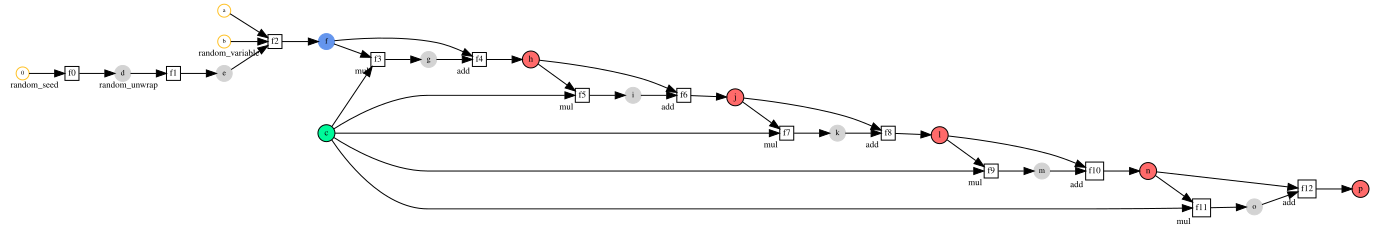

In [41]:
g

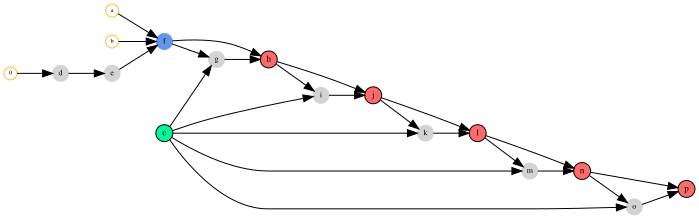

In [42]:
g2

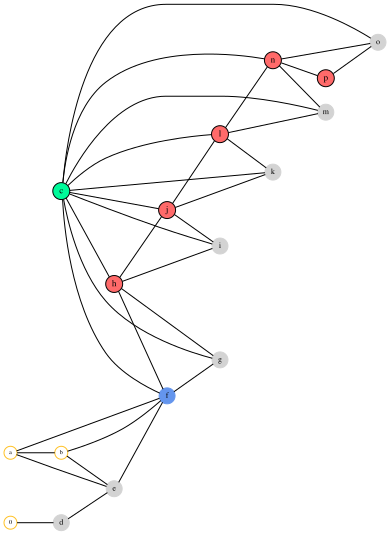

In [43]:
g3

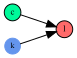

In [19]:
g4

In [20]:
nx.

SyntaxError: invalid syntax (2096355960.py, line 1)

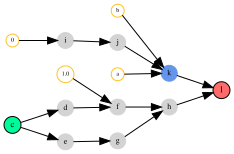

In [245]:
g2

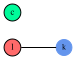

In [226]:
g3._graph = nx.subgraph(g3._graph, ["c", "l", "k"])
g3

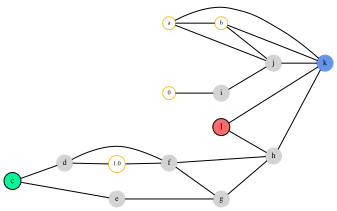

In [223]:
g3

In [13]:
from networkx.algorithms import bipartite

eqns = list(g.vars.keys())
subgraph = bipartite.projected_graph(g._graph, eqns)

type(subgraph)

networkx.classes.digraph.DiGraph

In [14]:
G = g._graph
G_new = nx.classes.graphviews.generic_graph_view(G)

In [111]:
import networkx as nx

def moralize(graph):
    moral_graph = graph.copy()

    for node in graph.nodes:
        parents = list(graph.predecessors(node))
        for i in range(len(parents)):
            for j in range(i + 1, len(parents)):
                moral_graph.add_edge(parents[i], parents[j])

    return moral_graph

def nami_graph_inversion(bn_structure, latent_variables, top_mode=True):
    J = moralize(bn_structure)
    J_nodes = set(J.nodes)

    H = nx.DiGraph()
    H.add_nodes_from(bn_structure.nodes)



    S = set(latent for latent in latent_variables if len(list(bn_structure.predecessors(latent))) == 0)
    print(S)
    while S:
        v = min(S, key=lambda node: len(set(J.neighbors(node)) - set(H.neighbors(node))))
        unmarked_neighbors = set(J.neighbors(v)) - set(H.neighbors(v))
        H.add_edges_from((v, neighbor) for neighbor in unmarked_neighbors if downstream in bn_structure.predecessors(neighbor))
        H.nodes[v]['marked'] = True
        S.remove(v)
        for u in (latent for latent in bn_structure.predecessors(v) if downstream in bn_structure.predecessors(latent)):
            if all(H.nodes[parent].get('marked') for parent in bn_structure.predecessors(u) if upstream in bn_structure.predecessors(parent)):
                S.add(u)
    return H


In [112]:
bn_structure = nx.DiGraph()
bn_structure.add_edges_from([('D', 'G'), ('I', 'G'), ('I', 'S'), ('S', 'J'), ('G', 'L'), ("G", "H"), ("J", "H")])

latent_variables = ["D", "I", "G", "S", "L"]

inverted_graph = nami_graph_inversion(bn_structure, latent_variables, top_mode=False)


{'D', 'I'}


NameError: name 'downstream' is not defined

In [108]:
list(bn_structure.predecessors("G"))

['D', 'I']

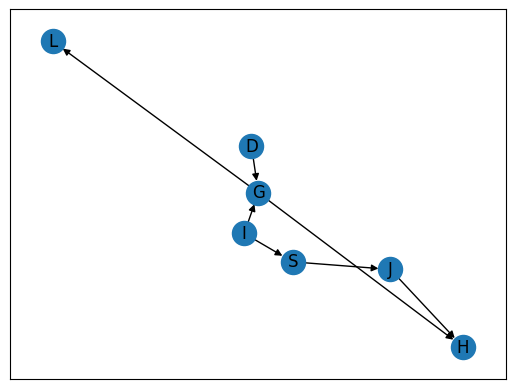

In [97]:
nx.draw_networkx(bn_structure, with_labels=True)

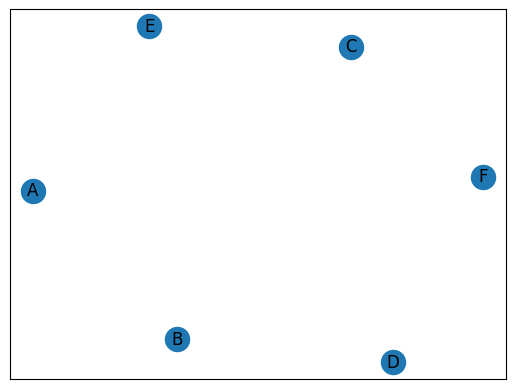

In [94]:
nx.draw_networkx(inverted_graph, with_labels=True)